In [ ]:
# baselines.ipynb
"""
Four baselines to compare against the MTL model:
# 1. logistic regression (demo + disease flags)
# 2. random forest (demo + disease flags)
# 3. STL neural network (demo + disease flags, no shared trunk)
# 4. MTL no diseases (demo only, shared trunk, no disease flag inputs)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import json
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

In [2]:
# Load everything the same way as always
data = pd.read_csv('saved/nhanes_clean.csv')

with open('saved/col_lists.json', 'r') as f:
    cols = json.load(f)

scaler = joblib.load('saved/demo_scaler.pkl')

demo_cols    = [c for c in cols['demo_cols'] if c not in ['SLQ300', 'SLQ310']]
disease_cols = cols['disease_cols']
disease_meta = cols['disease_meta']
continuous_cols = ['RIDAGEYR','BMXBMI','BMXWAIST','ALQ121','PAQ706','OCQ180','HUQ010','SBP','DBP']
data[continuous_cols] = scaler.transform(data[continuous_cols])

train_df, temp_df = train_test_split(data, test_size=0.30, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42)
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# pull architecture constants and circular pairs from checkpoint
checkpoint = torch.load('saved/mtl_model.pt', map_location='cpu')
CIRCULAR_PAIRS = {int(k): v for k, v in checkpoint['circular_pairs'].items()}
K = checkpoint['K']
n_demo = checkpoint['d_demo']
H = checkpoint['H']
dropout = checkpoint['dropout']

Train: 5088, Val: 1090, Test: 1091


In [ ]:
# Baseline 1 and 2 - LR and RF with demo + disease flags
"""
for each disease k, we use all other disease flags as inputs (same as MTL)
so the input is demo_cols + all disease_cols except k + circular
but we are looping over all diseases, there is no MTL happening.
"""

lr_preds = np.full((len(test_df), K), np.nan)
rf_preds = np.full((len(test_df), K), np.nan)

for k, col in enumerate(disease_cols):

    # input features = demo + all other disease flags (exclude target disease)
    other_diseases = [c for i, c in enumerate(disease_cols) 
                  if i != k and i not in CIRCULAR_PAIRS.get(k, [])]
    feature_cols   = demo_cols + other_diseases

    # drop rows where target label or any input disease flag is missing
    train_valid = train_df[col].notna()
    test_valid  = test_df[col].notna()

    X_tr = train_df.loc[train_valid, feature_cols].fillna(0).values.astype(float)
    X_te = test_df.loc[test_valid, feature_cols].fillna(0).values.astype(float)
    y_tr = train_df.loc[train_valid, col].values.astype(float)

    # logistic regression
    """
    Few bits worth mentioning given simplicity of following code:
    (1) BCE is used for the loss function, same as for MTL-NN
    (2) Default sklearn uses L-BFGS to optimise values, hence the iterations, cheaper than Newton, quicker than SGD
    (3) There is an implicit L2 regularisation by default, necessaey in LR.
    """
    lr = LogisticRegression(max_iter=1000, random_state=42) 
    lr.fit(X_tr, y_tr)
    lr_preds[test_valid.values, k] = lr.predict_proba(X_te)[:, 1]

    # random forest
    """
    For RFs:
    (1) No global optimum, instead greedy recursive partioning is used, minimising the Gini impurity.
    (2) Average is taken across 100 trees (n_estimators), to form the RF from the trees
    (3) No max depth set, trying to stay general for baseliness, bagging should help with generalisability
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 tries to use all CPU cores simultaenously
    rf.fit(X_tr, y_tr)
    rf_preds[test_valid.values, k] = rf.predict_proba(X_te)[:, 1]

    print(f'  {disease_meta[col]:30s} LR + RF done')

np.save('saved/lr_test_preds.npy', lr_preds)
np.save('saved/rf_test_preds.npy', rf_preds)
print('LR and RF predictions saved')

  Diabetes                       LR + RF done
  Pre-diabetes                   LR + RF done
  Hypertension                   LR + RF done
  High cholesterol               LR + RF done
  Arthritis                      LR + RF done
  Congestive heart failure       LR + RF done
  Coronary heart disease         LR + RF done
  Heart attack                   LR + RF done
  Stroke                         LR + RF done
  Liver condition                LR + RF done
  Thyroid problem                LR + RF done
  COPD/emphysema                 LR + RF done
  Cancer                         LR + RF done
  Kidney disease                 LR + RF done
  Asthma                         LR + RF done
LR and RF predictions saved


In [ ]:
# Baseline 3 - STL neural network, one per disease
"""
Same inputs as LR/RF (demo + other disease flags) but a single classification task.
No shared trunk - each disease trained completely independently.
Early stopping on val PRAUC with patience=20 to match MTL training protocol.
"""

class STLNet(nn.Module):
    def __init__(self, n_inputs, H=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H),        nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, 1),        nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

class STLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

EPOCHS   = 100
PATIENCE = 20

stl_preds = np.full((len(test_df), K), np.nan)

for k, col in enumerate(disease_cols):

    other_diseases = [c for i, c in enumerate(disease_cols)
                      if i != k and i not in CIRCULAR_PAIRS.get(k, [])]
    feature_cols = demo_cols + other_diseases
    n_inputs = len(feature_cols)

    train_valid = train_df[col].notna()
    val_valid   = val_df[col].notna()
    test_valid  = test_df[col].notna()

    X_tr = train_df.loc[train_valid, feature_cols].fillna(0).values.astype(float)
    X_va = val_df.loc[val_valid,     feature_cols].fillna(0).values.astype(float)
    X_te = test_df.loc[test_valid,   feature_cols].fillna(0).values.astype(float)
    y_tr = train_df.loc[train_valid, col].values.astype(float)
    y_va = val_df.loc[val_valid,     col].values.astype(float)

    stl_model = STLNet(n_inputs).to(device)
    optimizer = torch.optim.Adam(stl_model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    train_loader = DataLoader(STLDataset(X_tr, y_tr), batch_size=64, shuffle=True)

    best_val_prauc = 0.0
    patience_counter = 0
    best_state = None

    for epoch in range(EPOCHS):

        stl_model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = stl_model(X_batch.to(device)).squeeze()
            loss  = criterion(preds, y_batch.to(device))
            loss.backward()
            optimizer.step()

        stl_model.eval()
        with torch.no_grad():
            val_preds = stl_model(torch.tensor(X_va, dtype=torch.float32).to(device))
            val_preds = val_preds.cpu().numpy().squeeze()

        val_prauc = average_precision_score(y_va, val_preds)

        if val_prauc > best_val_prauc:
            best_val_prauc   = val_prauc
            patience_counter = 0
            best_state = stl_model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    stl_model.load_state_dict(best_state)
    stl_model.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
        stl_preds[test_valid.values, k] = stl_model(X_te_t).cpu().numpy().squeeze()

    print(f'  {disease_meta[col]:30s} stopped epoch {epoch+1:3d}  best val PRAUC {best_val_prauc:.3f}')

np.save('saved/stl_test_preds.npy', stl_preds)
print('STL predictions saved')

  Diabetes                       stopped epoch  22  best val PRAUC 0.487
  Pre-diabetes                   stopped epoch  21  best val PRAUC 0.373
  Hypertension                   stopped epoch  30  best val PRAUC 0.758
  High cholesterol               stopped epoch  34  best val PRAUC 0.728
  Arthritis                      stopped epoch  28  best val PRAUC 0.657
  Congestive heart failure       stopped epoch  25  best val PRAUC 0.456
  Coronary heart disease         stopped epoch  37  best val PRAUC 0.439
  Heart attack                   stopped epoch  26  best val PRAUC 0.377
  Stroke                         stopped epoch  31  best val PRAUC 0.196
  Liver condition                stopped epoch  27  best val PRAUC 0.149
  Thyroid problem                stopped epoch  31  best val PRAUC 0.326
  COPD/emphysema                 stopped epoch  26  best val PRAUC 0.383
  Cancer                         stopped epoch  33  best val PRAUC 0.432
  Kidney disease                 stopped epoch  24 

In [19]:
# Baseline 4 - MTL without disease flags
"""
Same architecture as the main model but disease flags are zeroed out
Isolates the value of disease inputs specifically
"""

# reload the MTL architecture
checkpoint = torch.load('saved/mtl_model.pt', map_location=device)

class MaskedMTLNet(nn.Module):
    def __init__(self, d_demo, K, H=128, dropout=0.3, circular_pairs=None):
        super().__init__()
        self.K = K
        self.circular_pairs = circular_pairs or {}
        self.trunk = nn.Sequential(
            nn.Linear(d_demo, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList()
        for k in range(K):
            n_masked = 1 + len(self.circular_pairs.get(k, []))
            self.heads.append(nn.Sequential(
                nn.Linear(H + (K - n_masked), H // 2), nn.ReLU(),
                nn.Linear(H // 2, 1), nn.Sigmoid()
            ))

    def forward(self, x_demo, d):
        h = self.trunk(x_demo)
        preds = []
        for k in range(self.K):
            exclude = {k} | set(self.circular_pairs.get(k, []))
            keep = [j for j in range(self.K) if j not in exclude]
            d_input = torch.nan_to_num(d[:, keep].clone(), nan=0.0)
            preds.append(self.heads[k](torch.cat([h, d_input], dim=1)))
        return torch.cat(preds, dim=1)

# retrain MTL from scratch with disease flags zeroed out during training
mtl_nodis = MaskedMTLNet(
    d_demo=checkpoint['d_demo'], K=checkpoint['K'],
    H=checkpoint['H'], dropout=checkpoint['dropout'],
    circular_pairs=checkpoint['circular_pairs']
).to(device)

class NHANESDataset(Dataset):
    def __init__(self, df, demo_cols, disease_cols):
        self.X = torch.tensor(df[demo_cols].values.astype(float), dtype=torch.float32)
        self.D = torch.tensor(df[disease_cols].values.astype(float), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.D[idx]

train_loader = DataLoader(NHANESDataset(train_df, demo_cols, disease_cols),
                          batch_size=64, shuffle=True)
test_loader  = DataLoader(NHANESDataset(test_df,  demo_cols, disease_cols),
                          batch_size=64, shuffle=False)

optimizer = torch.optim.Adam(mtl_nodis.parameters(), lr=1e-3)
criterion = nn.BCELoss(reduction='none')

# train for 100 epochs with disease flags zeroed out
for epoch in range(100):
    mtl_nodis.train()
    for x_demo, d in train_loader:
        x_demo = x_demo.to(device)
        d = d.to(device)

        # zero out all disease flags - model only sees demographics
        d_zeroed = torch.zeros_like(d)

        optimizer.zero_grad()
        preds = mtl_nodis(x_demo, d_zeroed)

        # NaN mask per head
        valid_mask = ~torch.isnan(d)
        loss = criterion(preds, torch.nan_to_num(d, nan=0.0))
        loss = (loss * valid_mask).sum() / valid_mask.sum()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'  epoch {epoch+1}/100 done')


optimizer = torch.optim.Adam(mtl_nodis.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss(reduction='none')

val_loader_nodis = DataLoader(NHANESDataset(val_df, demo_cols, disease_cols),
                              batch_size=64, shuffle=False)

EPOCHS   = 100
PATIENCE = 20
best_val_prauc   = 0.0
patience_counter = 0
best_state       = None

for epoch in range(EPOCHS):
    mtl_nodis.train()
    for x_demo, d in train_loader:
        x_demo = x_demo.to(device)
        d      = d.to(device)
        d_zeroed = torch.zeros_like(d)
        optimizer.zero_grad()
        preds = mtl_nodis(x_demo, d_zeroed)
        valid_mask = ~torch.isnan(d)
        loss = criterion(preds, torch.nan_to_num(d, nan=0.0))
        loss = (loss * valid_mask).sum() / valid_mask.sum()
        loss.backward()
        optimizer.step()

    # Validate on zeroed disease flags
    mtl_nodis.eval()
    val_preds_all, val_targets_all = [], []
    with torch.no_grad():
        for x_demo, d in val_loader_nodis:
            d_zeroed = torch.zeros_like(d)
            p = mtl_nodis(x_demo.to(device), d_zeroed)
            val_preds_all.append(p.cpu().numpy())
            val_targets_all.append(d.numpy())

    val_preds_all   = np.concatenate(val_preds_all,   axis=0)
    val_targets_all = np.concatenate(val_targets_all, axis=0)

    prauc_scores = []
    for k in range(K):
        valid = ~np.isnan(val_targets_all[:, k])
        if valid.sum() > 0 and val_targets_all[valid, k].sum() > 0:
            prauc_scores.append(
                average_precision_score(val_targets_all[valid, k], val_preds_all[valid, k])
            )
    val_prauc = np.mean(prauc_scores)

    if val_prauc > best_val_prauc:
        best_val_prauc   = val_prauc
        patience_counter = 0
        best_state       = mtl_nodis.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'  epoch {epoch+1} | val PRAUC {val_prauc:.4f}')

mtl_nodis.load_state_dict(best_state)
print(f'Best val PRAUC: {best_val_prauc:.4f}')

# get test predictions with disease flags zeroed out
mtl_nodis.eval()
mtl_nodis_preds = []
with torch.no_grad():
    for x_demo, d in test_loader:
        d_zeroed = torch.zeros_like(d)
        preds    = mtl_nodis(x_demo.to(device), d_zeroed)
        mtl_nodis_preds.append(preds.cpu().numpy())

mtl_nodis_preds = np.concatenate(mtl_nodis_preds, axis=0)
np.save('saved/mtl_nodis_test_preds.npy', mtl_nodis_preds)
print('MTL no-disease predictions saved')

  epoch 10/100 done
  epoch 20/100 done
  epoch 30/100 done
  epoch 40/100 done
  epoch 50/100 done
  epoch 60/100 done
  epoch 70/100 done
  epoch 80/100 done
  epoch 90/100 done
  epoch 100/100 done
  epoch 10 | val PRAUC 0.3108
  epoch 20 | val PRAUC 0.3095
  epoch 30 | val PRAUC 0.3134
  epoch 40 | val PRAUC 0.3174
  epoch 50 | val PRAUC 0.3203
  epoch 60 | val PRAUC 0.3224
  epoch 70 | val PRAUC 0.3221
  epoch 80 | val PRAUC 0.3198
  epoch 90 | val PRAUC 0.3216
  epoch 100 | val PRAUC 0.3250
Best val PRAUC: 0.3264
MTL no-disease predictions saved


In [21]:
# Final comparison table - all 5 models
mtl_preds = np.load('saved/mtl_test_preds.npy')
test_targets = np.load('saved/mtl_test_targets.npy')

models = {
    'LR': lr_preds,
    'RF': rf_preds,
    'ANN': stl_preds,
    'MTL no Dis': mtl_nodis_preds,
    'MTL': mtl_preds,
}

header = f"{'Disease':28s}" + ''.join(f"  {n:>10}" for n in models) + '  MTL vs best'
print(header)

macro = {n: [] for n in models}

for k, col in enumerate(disease_cols):
    valid = ~np.isnan(test_targets[:, k])
    t = test_targets[valid, k]
    row = f"  {disease_meta[col]:28s}"

    aurocs = {}
    for name, preds in models.items():
        a = roc_auc_score(t, preds[valid, k])
        aurocs[name] = a
        macro[name].append(a)

    # best baseline = best model excluding MTL itself
    best_baseline = max(v for k2, v in aurocs.items() if k2 != 'MTL')
    mtl_diff = aurocs['MTL'] - best_baseline

    for name, a in aurocs.items():
        flag = '*' if name == 'MTL' and mtl_diff > 0 else ' '
        row += f"  {a:.3f}{flag}    "

    # show MTL gain vs best baseline, + means MTL wins
    row += f"  {mtl_diff:+.3f}"
    print(row)

macro_row = f"  {'Macro average':28s}"
for name in models:
    macro_row += f"  {np.mean(macro[name]):.3f}     "

# macro MTL gain vs macro best baseline per disease
macro_diff = np.mean(macro['MTL']) - np.mean([max(macro[n][k] for n in models if n != 'MTL')
                                               for k in range(len(disease_cols))])
macro_row += f"  {macro_diff:+.3f}"
print(macro_row)

Disease                               LR          RF         ANN  MTL no Dis         MTL  MTL vs best
  Diabetes                      0.884       0.878       0.861       0.841       0.878       -0.006
  Pre-diabetes                  0.783       0.781       0.779       0.752       0.793*      +0.009
  Hypertension                  0.861       0.852       0.851       0.825       0.860       -0.002
  High cholesterol              0.818       0.812       0.804       0.779       0.822*      +0.004
  Arthritis                     0.820       0.798       0.808       0.788       0.813       -0.007
  Congestive heart failure      0.939       0.905       0.854       0.858       0.939       +0.000
  Coronary heart disease        0.896       0.904       0.837       0.797       0.890       -0.014
  Heart attack                  0.872       0.875       0.814       0.814       0.842       -0.032
  Stroke                        0.814       0.803       0.761       0.809       0.799       -0.015
  Liver

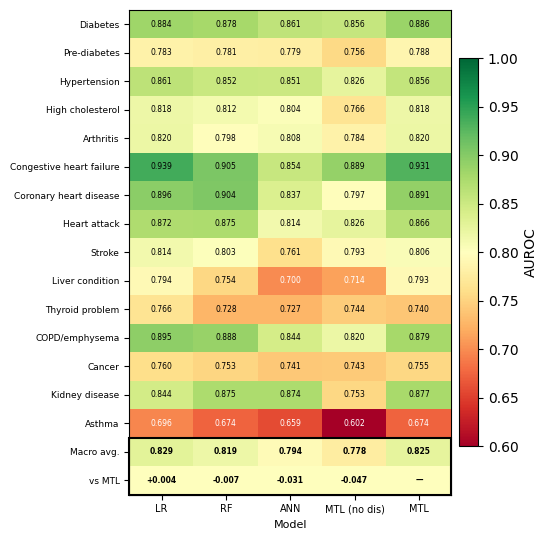

In [17]:
# Creating figure 2
model_names = ['LR', 'RF', 'ANN', 'MTL (no dis)', 'MTL']
disease_names = [disease_meta[col] for col in disease_cols]
mtl_idx = 4

preds_list = [lr_preds, rf_preds, stl_preds, mtl_nodis_preds, mtl_preds]

auroc_matrix = np.array([
    [
        roc_auc_score(test_targets[~np.isnan(test_targets[:, k]), k],
                      p[~np.isnan(test_targets[:, k]), k])
        for p in preds_list
    ]
    for k in range(K)
])  # shape (K, 5)

# build extended matrix: diseases + macro avg + delta row
avg_auroc = auroc_matrix.mean(axis=0)
delta_row = avg_auroc - avg_auroc[mtl_idx]

# delta row needs a neutral colour so use 0.8 as filler (mid-range on the cmap)
filler = np.full_like(delta_row, 0.8)
display_matrix = np.vstack([auroc_matrix, avg_auroc, filler])

fig1, ax1 = plt.subplots(figsize=(5.5, 5.5))
im = ax1.imshow(display_matrix, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0)

ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, fontsize=7)
ax1.set_yticks(range(K + 2))
ax1.set_yticklabels(disease_names + ['Macro avg.', 'vs MTL'], fontsize=6.5)
ax1.set_xlabel('Model', fontsize=8)

for i in range(K):
    for j in range(len(model_names)):
        v = display_matrix[i, j]
        col = 'white' if v < 0.72 else 'black'
        ax1.text(j, i, f'{v:.3f}', ha='center', va='center',
                 fontsize=5.5, color=col)

# macro avg row
for j in range(len(model_names)):
    v = avg_auroc[j]
    col = 'white' if v < 0.72 else 'black'
    ax1.text(j, K, f'{v:.3f}', ha='center', va='center',
             fontsize=5.5, color=col, fontweight='bold')

# delta row — bold, no italic
for j in range(len(model_names)):
    d = delta_row[j]
    sign = '+' if d > 0 else ''
    label = '—' if j == mtl_idx else f'{sign}{d:.3f}'
    ax1.text(j, K + 1, label, ha='center', va='center',
             fontsize=5.5, color='black', fontweight='bold')

# solid black border around macro avg + vs MTL rows
rect = Rectangle((-0.5, K - 0.5), len(model_names), 2,
                 linewidth=1.5, edgecolor='black', facecolor='none',
                 clip_on=False)
ax1.add_patch(rect)

ax1.set_ylim(K + 1.5, -0.5)
plt.colorbar(im, ax=ax1, label='AUROC', shrink=0.8, pad=0.02)
plt.tight_layout()
plt.savefig('saved/auroc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()